In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

mnist_data = datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())
mnist_data = list(mnist_data)[:4096]

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 503kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]


#### Architecture

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        encoding_dim = 32
        self.fc1 = nn.Linear(28 * 28, encoding_dim)
        self.fc2 = nn.Linear(encoding_dim, 28*28)

    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        x = F.relu(self.fc1(flattened))
        x = F.sigmoid(self.fc2(x))
        return x

#### Training an Autoencoder

In [ ]:
def train(model, num_epochs=5, batch_size=64, learning_rate=1e-3):
    torch.manual_seed(42)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=learning_rate,
                                 weight_decay=1e-5) 
    train_loader = torch.utils.data.DataLoader(mnist_data, batch_size=batch_size, shuffle=True)
    outputs = []
    for epoch in range(num_epochs):
        for data in train_loader:
            img, _ = data
            recon = model(img)
            img = img.view(-1, 28 * 28)
            loss = criterion(recon, img)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        print('Epoch:{}, Loss:{:.4f}'.format(epoch+1, float(loss)))
        outputs.append((epoch, img, recon),)
    return outputs

In [4]:
model = Autoencoder()
max_epochs = 20
outputs = train(model, num_epochs=max_epochs)

/tmp/ipython-input-450/1294450985.py:21: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('Epoch:{}, Loss:{:.4f}'.format(epoch+1, float(loss)))


Epoch:1, Loss:0.0688
Epoch:2, Loss:0.0636
Epoch:3, Loss:0.0532
Epoch:4, Loss:0.0487
Epoch:5, Loss:0.0443
Epoch:6, Loss:0.0384
Epoch:7, Loss:0.0394
Epoch:8, Loss:0.0370
Epoch:9, Loss:0.0364
Epoch:10, Loss:0.0334
Epoch:11, Loss:0.0272
Epoch:12, Loss:0.0309
Epoch:13, Loss:0.0336
Epoch:14, Loss:0.0281
Epoch:15, Loss:0.0253
Epoch:16, Loss:0.0251
Epoch:17, Loss:0.0241
Epoch:18, Loss:0.0231
Epoch:19, Loss:0.0231
Epoch:20, Loss:0.0221


### Convolutional Autoencoder

#### Convolution Transpose

In [ ]:
conv = nn.Conv2d(in_channels=8,out_channels=8, kernel_size=5)

In [6]:
x = torch.randn(2, 8, 64, 64)
y = conv(x)
y.shape

torch.Size([2, 8, 60, 60])

In [ ]:
convt = nn.ConvTranspose2d(in_channels=8, out_channels=8, kernel_size=5)
convt(y).shape 

torch.Size([2, 8, 64, 64])

In [8]:
x = torch.randn(32, 8, 64, 64)
y = convt(x)
y.shape

torch.Size([32, 8, 68, 68])

In [ ]:
conv = nn.Conv2d(in_channels=8, out_channels=16,kernel_size=5)
y = torch.randn(32, 8, 68, 68)
x = conv(y)
x.shape

torch.Size([32, 16, 64, 64])

In [ ]:
convt = nn.ConvTranspose2d(in_channels=16,out_channels=8,kernel_size=5, padding=2)
x = torch.randn(32, 16, 64, 64)
y = convt(x)
y.shape

torch.Size([32, 8, 64, 64])

In [ ]:
convt = nn.ConvTranspose2d(in_channels=16,
                           out_channels=8,
                           kernel_size=5,
                           stride=2,
                           output_padding=1, 
                           padding=0)
x = torch.randn(32, 16, 64, 64)
y = convt(x)
y.shape

torch.Size([32, 8, 132, 132])

### Implementation of a Convolutional Autoencoder

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential( 
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 7)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
# Eencoder
nn.Conv2d(1, 16, 3, stride=2, padding=1),
nn.Conv2d(16, 32, 3, stride=2, padding=1),
nn.Conv2d(32, 64, 7)

# Decoder
nn.ConvTranspose2d(64, 32, 7),
nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),

(ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1)),)

#### Training a Convolutional Autoencoder

In [ ]:
def train(model, num_epochs=5, batch_size=64, learning_rate=1e-3):
    torch.manual_seed(42)
    criterion = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=learning_rate,
                                 weight_decay=1e-5)
    train_loader = torch.utils.data.DataLoader(mnist_data,
                                               batch_size=batch_size,
                                               shuffle=True)
    outputs = []
    for epoch in range(num_epochs):
        for data in train_loader:
            img, _ = data
            recon = model(img)
            loss = criterion(recon, img)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        print('Epoch:{}, Loss:{:.4f}'.format(epoch+1, float(loss)))
        outputs.append((epoch, img, recon),)
    return outputs

In [15]:
model = Autoencoder()
max_epochs = 20
outputs = train(model, num_epochs=max_epochs)

Epoch:1, Loss:0.0673
Epoch:2, Loss:0.0653
Epoch:3, Loss:0.0453
Epoch:4, Loss:0.0325
Epoch:5, Loss:0.0238
Epoch:6, Loss:0.0176
Epoch:7, Loss:0.0154
Epoch:8, Loss:0.0148
Epoch:9, Loss:0.0139
Epoch:10, Loss:0.0105
Epoch:11, Loss:0.0086
Epoch:12, Loss:0.0090
Epoch:13, Loss:0.0101
Epoch:14, Loss:0.0080
Epoch:15, Loss:0.0072
Epoch:16, Loss:0.0074
Epoch:17, Loss:0.0070
Epoch:18, Loss:0.0064
Epoch:19, Loss:0.0058
Epoch:20, Loss:0.0062


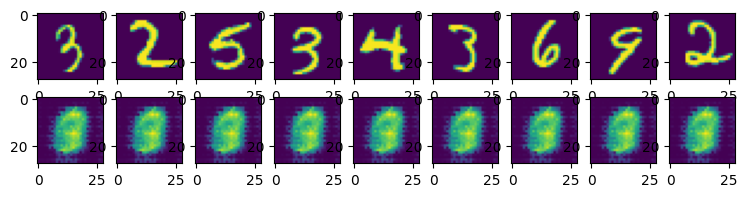

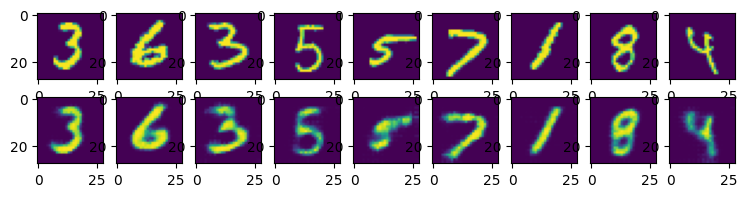

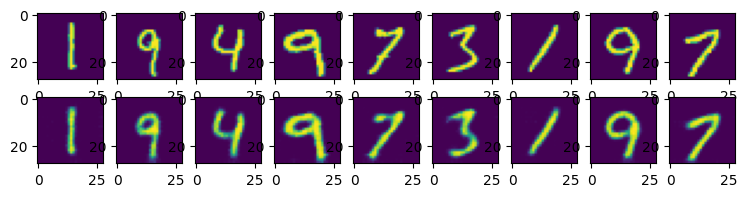

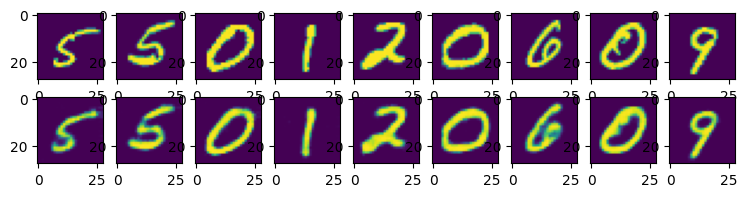

In [16]:
for k in range(0, max_epochs, 5):
    plt.figure(figsize=(9, 2))
    imgs = outputs[k][1].detach().numpy()
    recon = outputs[k][2].detach().numpy()
    for i, item in enumerate(imgs):
        if i >= 9: break
        plt.subplot(2, 9, i+1)
        plt.imshow(item[0])

    for i, item in enumerate(recon):
        if i >= 9: break
        plt.subplot(2, 9, 9+i+1)
        plt.imshow(item[0])

## Part 4: Denoising Autoencoder

In [ ]:
def train(model, num_epochs=5, batch_size=64, learning_rate=1e-3):
    torch.manual_seed(42)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=learning_rate,
                                 weight_decay=1e-5)
    train_loader = torch.utils.data.DataLoader(mnist_data,
                                               batch_size=batch_size,
                                               shuffle=True)
    noise = 0.5
    outputs = []
    for epoch in range(num_epochs):
        for data in train_loader:
            img, _ = data

            img_noisy = img + noise * torch.randn(*img.shape)
            img_noisy = np.clip(img_noisy, 0., 1.)

            recon = model(img_noisy)
            
            loss = criterion(recon, img)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        print('Epoch:{}, Loss:{:.4f}'.format(epoch+1, float(loss)))
        outputs.append((epoch, img_noisy, recon),)
    return outputs

In [ ]:
import numpy as np

model = Autoencoder()
max_epochs = 20
outputs = train(model, num_epochs=max_epochs)

Epoch:1, Loss:0.0679
Epoch:2, Loss:0.0610
Epoch:3, Loss:0.0696
Epoch:4, Loss:0.0690
Epoch:5, Loss:0.0666
Epoch:6, Loss:0.0619
Epoch:7, Loss:0.0518
Epoch:8, Loss:0.0385
Epoch:9, Loss:0.0303
Epoch:10, Loss:0.0294
Epoch:11, Loss:0.0247
Epoch:12, Loss:0.0240
Epoch:13, Loss:0.0219
Epoch:14, Loss:0.0198
Epoch:15, Loss:0.0175
Epoch:16, Loss:0.0199
Epoch:17, Loss:0.0174
Epoch:18, Loss:0.0181
Epoch:19, Loss:0.0168
Epoch:20, Loss:0.0176


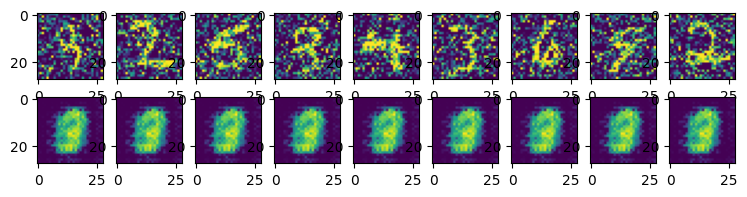

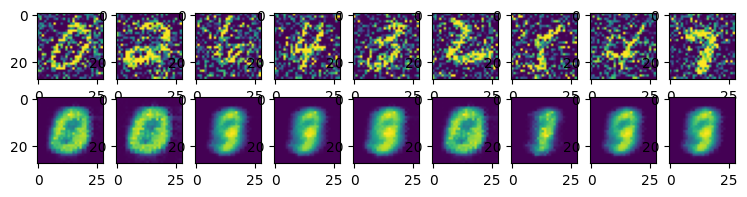

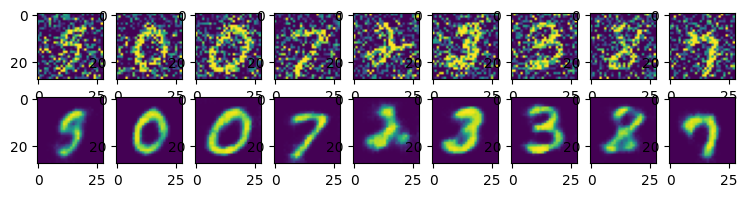

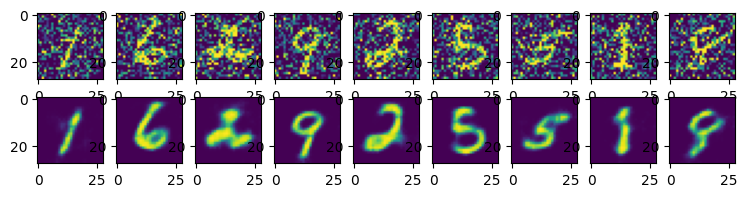

In [ ]:
for k in range(0, max_epochs, 5):
    plt.figure(figsize=(9, 2))
    imgs = outputs[k][1].detach().numpy()
    recon = outputs[k][2].detach().numpy()
    for i, item in enumerate(imgs):
        if i >= 9: break
        plt.subplot(2, 9, i+1)
        plt.imshow(item[0])

    for i, item in enumerate(recon):
        if i >= 9: break
        plt.subplot(2, 9, 9+i+1)
        plt.imshow(item[0])

### Testing on new images

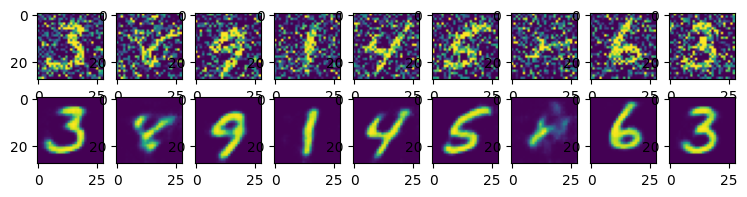

In [ ]:
batch_size = 64

mnist_data = datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())
mnist_data = list(mnist_data)[4096:4160]

test_loader = torch.utils.data.DataLoader(mnist_data,
                                           batch_size=batch_size,
                                           shuffle=True)

dataiter = iter(test_loader)
img, labels = next(dataiter)

# Add noise to the test images
noise = 0.5
img_noisy = img + noise * torch.randn(*img.shape)
img_noisy = np.clip(img_noisy, 0., 1.)

# Get sample outputs
recon = model(img_noisy)
img_noisy = img_noisy.numpy()
recon = recon.detach().numpy()

for k in range(1):
    plt.figure(figsize=(9, 2))

    for i, item in enumerate(img_noisy):
        if i >= 9: break
        plt.subplot(2, 9, i+1)
        plt.imshow(item[0])

    for i, item in enumerate(recon):
        if i >= 9: break
        plt.subplot(2, 9, 9+i+1)
        plt.imshow(item[0])

### Exploring the Latent Space

#### Structure in the Embeddings

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

mnist_data = datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())
mnist_data = list(mnist_data)[:4096]


class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 7)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def train(model, num_epochs=5, batch_size=64, learning_rate=1e-3):
    torch.manual_seed(42)
    criterion = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=learning_rate,
                                 weight_decay=1e-5)
    train_loader = torch.utils.data.DataLoader(mnist_data,
                                               batch_size=batch_size,
                                               shuffle=True)
    outputs = []
    for epoch in range(num_epochs):
        for data in train_loader:
            img, _ = data
            recon = model(img)
            loss = criterion(recon, img)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        print('Epoch:{}, Loss:{:.4f}'.format(epoch+1, float(loss)))
        outputs.append((epoch, img, recon),)
    return outputs

In [22]:
model = Autoencoder()
max_epochs = 20
outputs = train(model, num_epochs=max_epochs)

Epoch:1, Loss:0.0670
Epoch:2, Loss:0.0668
Epoch:3, Loss:0.0493
Epoch:4, Loss:0.0335
Epoch:5, Loss:0.0251
Epoch:6, Loss:0.0190
Epoch:7, Loss:0.0162
Epoch:8, Loss:0.0160
Epoch:9, Loss:0.0150
Epoch:10, Loss:0.0117
Epoch:11, Loss:0.0093
Epoch:12, Loss:0.0098
Epoch:13, Loss:0.0107
Epoch:14, Loss:0.0088
Epoch:15, Loss:0.0078
Epoch:16, Loss:0.0083
Epoch:17, Loss:0.0076
Epoch:18, Loss:0.0071
Epoch:19, Loss:0.0064
Epoch:20, Loss:0.0064


Output two sample images

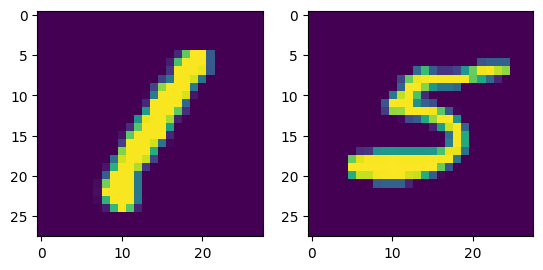

In [23]:
imgs = outputs[max_epochs-1][1].detach().numpy()
plt.subplot(1, 2, 1)
plt.imshow(imgs[0][0])
plt.subplot(1, 2, 2)
plt.imshow(imgs[8][0])

We will then compute the **low-dimensional embeddings** of both images,
by applying the **encoder**:

In [ ]:
x1 = outputs[max_epochs-1][1][0,:,:,:] # First image
x2 = outputs[max_epochs-1][1][8,:,:,:] # Second image
x = torch.stack([x1,x2]) # Stack them together so we only call `encoder` once
embedding = model.encoder(x)
e1 = embedding[0] # embedding of first image
e2 = embedding[1] # Embedding of second image

In [25]:
embedding_values = []
for i in range(0, 10):
    e = e1 * (i/10) + e2 * (10-i)/10
    embedding_values.append(e)
embedding_values = torch.stack(embedding_values)

recons = model.decoder(embedding_values)

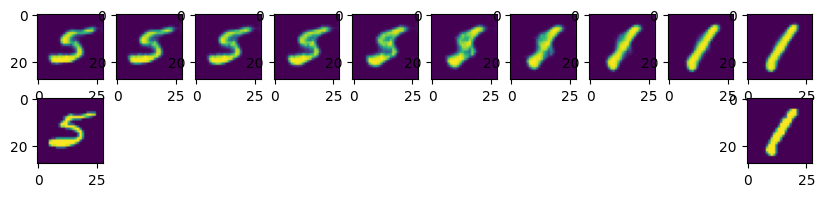

In [26]:
plt.figure(figsize=(10, 2))
for i, recon in enumerate(recons.detach().numpy()):
    plt.subplot(2,10,i+1)
    plt.imshow(recon[0])
plt.subplot(2,10,11)
plt.imshow(imgs[8][0])
plt.subplot(2,10,20)
plt.imshow(imgs[0][0])

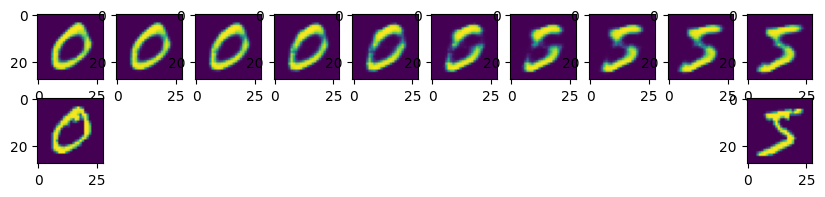

In [ ]:
def interpolate(index1, index2):
    x1 = mnist_data[index1][0]
    x2 = mnist_data[index2][0]
    x = torch.stack([x1,x2])
    embedding = model.encoder(x)
    e1 = embedding[0] 
    e2 = embedding[1] 

    embedding_values = []
    for i in range(0, 10):
        e = e1 * (i/10) + e2 * (10-i)/10
        embedding_values.append(e)
    embedding_values = torch.stack(embedding_values)

    recons = model.decoder(embedding_values)

    plt.figure(figsize=(10, 2))
    for i, recon in enumerate(recons.detach().numpy()):
        plt.subplot(2,10,i+1)
        plt.imshow(recon[0])
    plt.subplot(2,10,11)
    plt.imshow(x2[0])
    plt.subplot(2,10,20)
    plt.imshow(x1[0])

interpolate(0, 1)

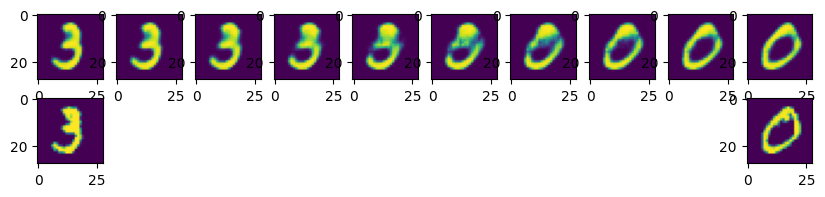

In [28]:
interpolate(1, 10)

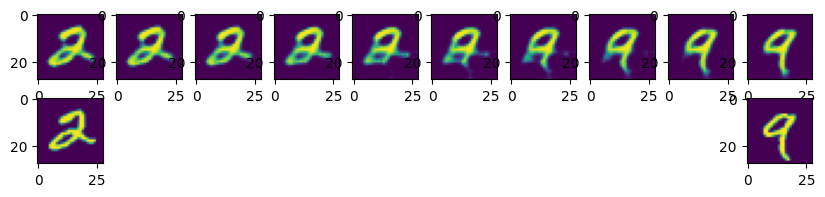

In [29]:
interpolate(4, 5)

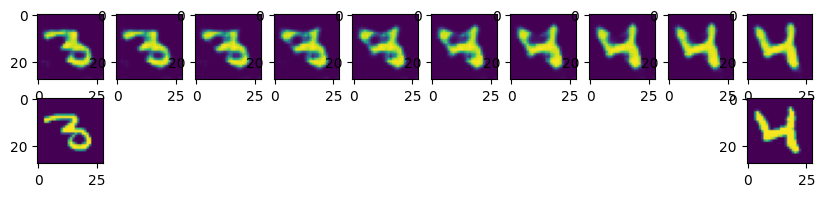

In [30]:
interpolate(20, 30)

In [31]:
def interpolate_pixel(index1, index2):
    x1 = mnist_data[index1][0]
    x2 = mnist_data[index2][0]

    interpolated_values = []
    for i in range(0, 10):
        e = x1 * (i/10) + x2 * (10-i)/10
        interpolated_values.append(e)

    plt.figure(figsize=(10, 2))
    for i, recon in enumerate(interpolated_values):
        plt.subplot(2,10,i+1)
        plt.imshow(recon[0])
    plt.subplot(2,10,11)
    plt.imshow(x2[0])
    plt.subplot(2,10,20)
    plt.imshow(x1[0])

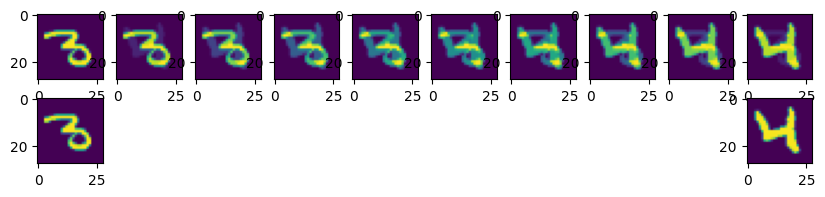

In [32]:
interpolate_pixel(20, 30)

What happens if we randomly initialize in the embedding space?

In [33]:
d = model.decoder(torch.randn(1, 64, 1, 1)).detach().numpy()

In [34]:
d.shape

(1, 1, 28, 28)

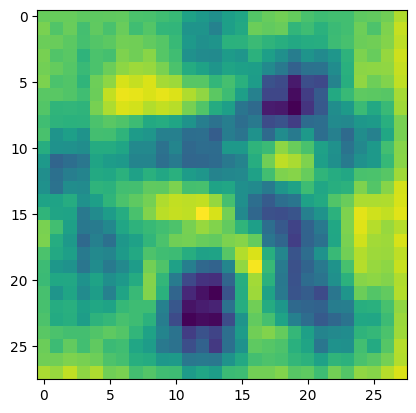

In [35]:
plt.imshow(d[0][0])

### Part 6: Variational Autoencoder (VAE)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('data', train=True, download=True,
                   transform=transforms.ToTensor()),
                   batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('data', train=False, transform=transforms.ToTensor()),
    batch_size=64, shuffle=True)


In [ ]:
zdim = 25

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(28 * 28, 350)
        self.relu = nn.ReLU()
        self.fc2m = nn.Linear(350, zdim)  # mu layer
        self.fc2s = nn.Linear(350, zdim)  # std layer

        # Decoder
        self.fc3 = nn.Linear(zdim, 350)
        self.fc4 = nn.Linear(350, 28 * 28)
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h1 = self.relu(self.fc1(x))
        return self.fc2m(h1), self.fc2s(h1)

    # Reparameterize
    def reparameterize(self, mu, logvar):
        if self.training:
            std = logvar.mul(0.5).exp_()
            eps = std.data.new(std.size()).normal_()
            return eps.mul(std).add_(mu)
        else:
            return mu

    def decode(self, z):
        h3 = self.relu(self.fc3(z))
        return self.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 28 * 28))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [ ]:
# Loss function for VAE are unique and use Kullback-Leibler
# Divergence measure to force distribution to match unit Gaussian
def loss_function(recon_x, x, mu, logvar):
    bce = F.binary_cross_entropy(recon_x, x.view(-1, 28 * 28))
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kld /= batch_size * 28 * 28
    return bce + kld

In [ ]:
def train(model, num_epochs = 1, batch_size = 64, learning_rate = 1e-3):
    model.train() 
    torch.manual_seed(42)

    train_loader = torch.utils.data.DataLoader(datasets.MNIST('data',
               train=True, download=True, transform=transforms.ToTensor()),
               batch_size = batch_size, shuffle = True)

    optimizer = optim.Adam(model.parameters(), learning_rate)

    for epoch in range(num_epochs):
      for data in train_loader: 
          img, _ = data

          recon, mu, logvar = model(img)
          loss = loss_function(recon, img, mu, logvar)
          loss.backward()
          optimizer.step()
          optimizer.zero_grad()

      print('Epoch:{}, Loss:{:.4f}'.format(epoch+1, float(loss)))

In [ ]:
batch_size = 64

model = Autoencoder()
train(model, num_epochs = 30, batch_size = batch_size)

Epoch:1, Loss:0.1589
Epoch:2, Loss:0.1419


In [ ]:
model.eval()
sample = torch.randn(64, zdim)
sample = model.decode(sample)

import matplotlib.pyplot as plt
imgs = sample.data.view(64, 28, 28).numpy()
plt.imshow(imgs[4])

In [ ]:
for k in range(1):
    plt.figure(figsize=(8, 8))

    for i, item in enumerate(imgs):
        plt.subplot(8, 8, i+1)
        plt.imshow(item)